# DFT-LRP sanity check (ECG)

This notebook mirrors the upstream `DFT-LRP` tutorial structure, but runs on **your model** and **your data**.

It computes **time-domain LRP relevance** for the positive logit and propagates it to **frequency** and **time–frequency** domains using the official DFT-LRP implementation.


In [ ]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import torch
import wandb
import matplotlib.pyplot as plt

def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src" / "ecg_chagas_embeddings").exists():
            return p
    return start

REPO_ROOT = _find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)
print("cwd:", Path.cwd())

# Local src/ layout
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

# Upstream DFT-LRP submodule (expects imports like `import dft_lrp`)
DFT_LRP_CODE_ROOT = REPO_ROOT / "external" / "dft-lrp" / "code"
if str(DFT_LRP_CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(DFT_LRP_CODE_ROOT))

import dft_lrp  # noqa: E402

from ecg_chagas_embeddings.data.datamodule import ECGDataModule # noqa: E402
from ecg_chagas_embeddings.models.resnet18_ecg_flex import LitResNet18 # noqa: E402
import importlib # noqa: E402
import ecg_chagas_embeddings.callbacks.xai_probe as xai_probe # noqa: E402
importlib.reload(xai_probe)
compute_lrp_relevance_time = xai_probe.compute_lrp_relevance_time

torch.set_float32_matmul_precision("high")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("device:", device)


/home/flo178/projects/master-thesis/ecg-chagas-embeddings/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/flo178/projects/master-thesis/ecg-chagas-embeddings/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annota

cwd: /home/flo178/projects/master-thesis/ecg-chagas-embeddings
torch: 2.9.0+cu128
device: cpu


/home/flo178/projects/master-thesis/ecg-chagas-embeddings/.venv/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


## 1) Download checkpoint from W&B

Paste the model artifact reference (same structure as the W&B UI snippet):
- `<entity>/<project>/<artifact>:<alias-or-version>`


In [2]:
WANDB_ARTIFACT = "ag-lukassen/ecg-chagas-embeddings-cli/model-6mz86f64:v5"  # <-- edit
DOWNLOAD_DIR = Path("./artifacts/wandb_downloads").resolve()
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

run = wandb.init(job_type="dft_lrp_sanity")
artifact = run.use_artifact(WANDB_ARTIFACT, type="model")
artifact_dir = Path(artifact.download(root=str(DOWNLOAD_DIR)))

ckpts = sorted(artifact_dir.rglob("*.ckpt"))
if not ckpts:
    raise FileNotFoundError(f"No .ckpt found under {artifact_dir}")
ckpt_path = ckpts[0]
print("Downloaded:", ckpt_path)
run.finish()
ckpt_path


wandb: Currently logged in as: floherzler (ag-lukassen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb:   1 of 1 files downloaded.  


Downloaded: /home/flo178/projects/master-thesis/ecg-chagas-embeddings/artifacts/wandb_downloads/model.ckpt


PosixPath('/home/flo178/projects/master-thesis/ecg-chagas-embeddings/artifacts/wandb_downloads/model.ckpt')

## 2) Point to your validation data

Defaults are taken from `configs/base.yaml` if env vars are not set:
- `ECG_META_PATH`
- `ECG_DATA_DIR`


In [3]:
def _parse_base_yaml_paths(path: Path) -> tuple[str | None, str | None]:
    text = path.read_text(encoding="utf-8")
    meta_path = None
    data_dir = None
    in_data = False
    for line in text.splitlines():
        if line.strip() == "data:":
            in_data = True
            continue
        if in_data and line and not line.startswith(" "):
            in_data = False
        if not in_data:
            continue
        s = line.strip()
        if s.startswith("meta_path:"):
            meta_path = s.split(":", 1)[1].strip().strip(""").strip("'")
        elif s.startswith("data_dir:"):
            data_dir = s.split(":", 1)[1].strip().strip(""").strip("'")
    return meta_path, data_dir

DEFAULT_META_PATH = None
DEFAULT_DATA_DIR = None
base_yaml = REPO_ROOT / "configs" / "base.yaml"
if base_yaml.exists():
    DEFAULT_META_PATH, DEFAULT_DATA_DIR = _parse_base_yaml_paths(base_yaml)
if not DEFAULT_META_PATH or not DEFAULT_DATA_DIR:
    default_root = REPO_ROOT.parent / "datasets" / "physionet2025" / "processedMaster"
    DEFAULT_META_PATH = str(default_root / "metadata.csv")
    DEFAULT_DATA_DIR = str(default_root / "bp_sc_norm")

META_PATH = os.environ.get("ECG_META_PATH") or DEFAULT_META_PATH
DATA_DIR = os.environ.get("ECG_DATA_DIR") or DEFAULT_DATA_DIR
META_PATH = str(Path(META_PATH).expanduser())
DATA_DIR = str(Path(DATA_DIR).expanduser())

assert Path(META_PATH).exists(), f"metadata.csv not found at {META_PATH} (set ECG_META_PATH to override)"
assert Path(DATA_DIR).exists(), f"tensor folder not found at {DATA_DIR} (set ECG_DATA_DIR to override)"

META_PATH, DATA_DIR


('/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/metadata.csv',
 '/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/bp_sc_norm')

## 3) Load model + fetch a validation sample

We compute relevance for the **same 2500-sample window** that your model sees.
For visualization, we pick a single lead (default: lead 1 / index 1).


In [4]:
FS_HZ = 400.0
LEAD_INDEX = 1  # choose lead to visualize (0..11)

# Use fold 4 (held-out) so the model has not seen these exams during training.
EVAL_FOLDS = (4,)
TARGET_CASE = "neg"  # "pos" or "neg"
AUTO_PICK_EXAMS = True

# Fallback ids (picked from fold-4, chagas=1/0, qc_zhao2018_bp=Excellent, qc_templatematch_bp~1.0)
EXAM_IDS = {"pos": "856135", "neg": "3411408"}

def _pick_fold4_exam_ids(meta_path: str, data_dir: str, fold: int = 4) -> dict[str, str]:
    import numpy as np
    import pandas as pd
    from pathlib import Path

    usecols = [
        "exam_id",
        "patient_id",
        "chagas",
        "fold",
        "qc_zhao2018_bp",
        "qc_templatematch_bp",
    ]
    df = pd.read_csv(meta_path, usecols=usecols, low_memory=False)
    df = df[(df["fold"] == fold) & df["qc_zhao2018_bp"].eq("Excellent")]
    df = df[np.isfinite(df["qc_templatematch_bp"])]

    processed_root = Path(data_dir).resolve().parent
    required_dirs = [processed_root / "bp", processed_root / "bp_sc", processed_root / "bp_sc_norm"]

    def _exists_all(exam_id: str) -> bool:
        return all((d / f"{exam_id}.pt").is_file() for d in required_dirs)

    out: dict[str, str] = {}
    for name, label in [("neg", 0), ("pos", 1)]:
        sub = df[df["chagas"] == label].sort_values("qc_templatematch_bp", ascending=False)
        for eid in sub["exam_id"].astype(str).head(20000):
            if _exists_all(eid):
                out[name] = eid
                break

    return out

if AUTO_PICK_EXAMS:
    try:
        picked = _pick_fold4_exam_ids(META_PATH, DATA_DIR, fold=EVAL_FOLDS[0])
        EXAM_IDS.update({k: v for k, v in picked.items() if v})
    except Exception as e:
        print("[WARN] Auto-pick from metadata failed; using fallback EXAM_IDS. Error:", e)

TARGET_EXAM_ID = EXAM_IDS[TARGET_CASE]
print("Using fold-4 exam ids:", EXAM_IDS, "| TARGET_CASE=", TARGET_CASE, "| TARGET_EXAM_ID=", TARGET_EXAM_ID)

model = LitResNet18.load_from_checkpoint(str(ckpt_path), log_umap=False)
model.to(device).eval()

dm = ECGDataModule(
    meta_path=META_PATH,
    data_dir=DATA_DIR,
    batch_size=64,
    num_workers=0,
    prefetch_factor=2,
    train_folds=(0, 1, 2, 3),
    valid_folds=EVAL_FOLDS,
    oversample=False,
    pos_fraction=0.05,
)
dm.setup("fit")
val_loader = dm.val_dataloader()

# Fetch the exact exam by id from the fold-4 dataset (ensures we're not accidentally visualizing fold-3).
val_ds = val_loader.dataset
matches = np.where(val_ds.metadata["exam_id"].astype(str).values == str(TARGET_EXAM_ID))[0]
assert len(matches) > 0, f"exam_id={TARGET_EXAM_ID} not found in fold {EVAL_FOLDS}"
sample = val_ds[int(matches[0])]

x = sample.get("ecg")
if x is None and "ecg_views" in sample:
    x = sample["ecg_views"][0]
y = sample["chagas"].view(-1)
exam_id = sample.get("exam_id")

x = x.unsqueeze(0).to(device=device, dtype=torch.float32)  # [1,12,2500]
y = y.to(device=device)
sample_idx = 0

with torch.no_grad():
    logits = model(x)
    if isinstance(logits, (tuple, list)):
        logits = logits[-1]
    if logits.ndim == 2 and logits.shape[1] == 1:
        logits = logits[:, 0]
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).to(torch.int64)

y_int = (y > 0.5).to(torch.int64)
print("label=", int(y_int[sample_idx].item()), "pred=", int(preds[sample_idx].item()))
print("exam_id=", exam_id)
prob_sample = float(probs[sample_idx].item())
logit_sample = float(logits[sample_idx].item())
print("p(chagas)=", prob_sample, "logit=", logit_sample)


Using fold-4 exam ids: {'pos': '856135', 'neg': '3411408'} | TARGET_CASE= neg | TARGET_EXAM_ID= 3411408
Train Transform kwargs: {'crop_size': 2500, 'n_views': 2, 'max_mask_duration': 50, 'time_mask_apply_prob': 1.0, 'mask_prob': 0.5, 'channel_mask_apply_prob': 1.0, 'gaussian_noise_std': 0.01, 'per_view_noise': True, 'scaling': (0.8, 1.2), 'per_view_scaling': True, 'max_time_warp': 0.2, 'per_view_warp': False, 'wandering_max_amplitude': 1.0, 'wandering_frequency_range': (0.5, 2.0), 'per_view_wandering': False}
label= 0 pred= 0
exam_id= 3411408
p(chagas)= 0.014835878275334835 logit= -4.1957597732543945


## 4) DFT-LRP (time → frequency / time–frequency) + plotting (3×2 grid)

This is the same structure as the upstream tutorial: time signal + relevance, time–frequency signal + relevance, frequency magnitude + relevance.


/home/flo178/projects/master-thesis/ecg-chagas-embeddings/external/dft-lrp/code/dft_lrp.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(input, dtype=dtype)


STDFT window_width= 125 n_windows= 20


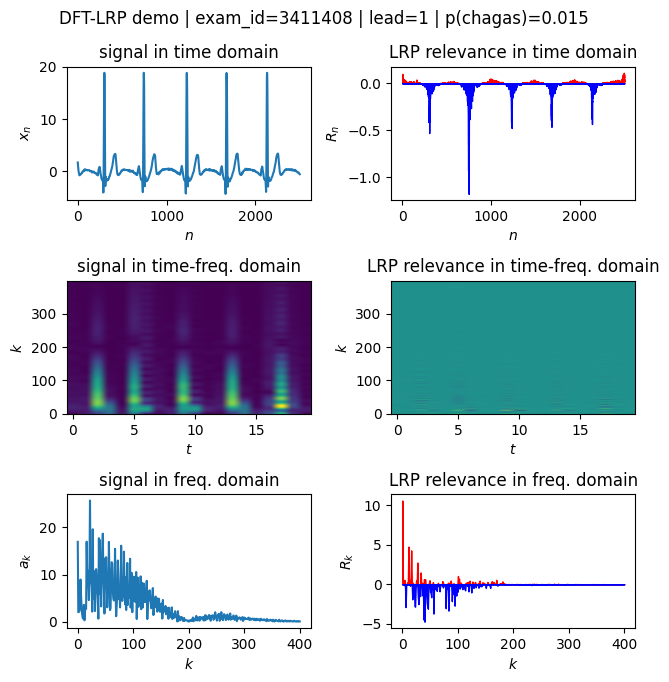

In [5]:
def replace_positive(x: np.ndarray, positive: bool = True) -> np.ndarray:
    mask = x > 0 if positive else x < 0
    x_mod = x.copy()
    x_mod[mask] = 0
    return x_mod

# Compute time-domain LRP relevance for the full multi-lead input
with torch.inference_mode(False), torch.enable_grad(), torch.autocast(device_type=device.type, enabled=False):
    relevance_time = compute_lrp_relevance_time(pl_module=model, x=x)  # [B,12,2500]

T = x.shape[-1]
signal_time = x[:, LEAD_INDEX, :].detach().cpu().numpy()
relevance_time_1d = relevance_time[:, LEAD_INDEX, :].detach().cpu().numpy()

# --- DFT-LRP to frequency domain ---
dftlrp = dft_lrp.DFTLRP(
    T,
    leverage_symmetry=True,
    precision=32,
    cuda=(device.type == "cuda"),
    create_stdft=False,
    create_inverse=False,
)

signal_freq, relevance_freq = dftlrp.dft_lrp(
    relevance_time_1d[[sample_idx]],
    signal_time[[sample_idx]],
    real=False,
    short_time=False,
    epsilon=1e-6,
)

# --- DFT-LRP to time–frequency domain (STDFT) ---
# Note: upstream STDFT uses DFT length = T. Its inverse normalizes by window coverage;
# if `window_width` does not divide `T`, the tail is uncovered -> divide-by-zero -> NaNs.
def _choose_window_width(signal_length: int, preferred: int = 128, min_w: int = 32, max_w: int = 512) -> int:
    upper = min(max_w, signal_length)
    candidates = [w for w in range(min_w, upper + 1) if signal_length % w == 0]
    if not candidates:
        return signal_length
    return min(candidates, key=lambda w: abs(w - preferred))

WINDOW_WIDTH = _choose_window_width(T, preferred=128)
WINDOW_SHIFT = 1
print("STDFT window_width=", WINDOW_WIDTH, "n_windows=", T // WINDOW_WIDTH)
dftlrp_tf = dft_lrp.DFTLRP(
    T,
    leverage_symmetry=True,
    precision=32,
    cuda=(device.type == "cuda"),
    window_shift=WINDOW_SHIFT,
    window_width=WINDOW_WIDTH,
    window_shape="rectangle",
    create_dft=False,
    create_inverse=False,
)
signal_timefreq, relevance_timefreq = dftlrp_tf.dft_lrp(
    relevance_time_1d[[sample_idx]],
    signal_time[[sample_idx]],
    real=False,
    short_time=True,
    epsilon=1e-6,
)

signal_timefreq = np.nan_to_num(signal_timefreq, nan=0.0, posinf=0.0, neginf=0.0)
relevance_timefreq = np.nan_to_num(relevance_timefreq, nan=0.0, posinf=0.0, neginf=0.0)

# Plot (adapted from upstream tutorial)
k_max = min(400, relevance_freq.shape[-1])  # use <=~64 Hz for fs=400, T=2500 => ~0.16 Hz/bin
nrows, ncols = 3, 2
figsize = (2 * 3.29, 2 * 3.29 / ncols * nrows * 1.4 / 2)
fig, ax = plt.subplots(nrows, ncols, figsize=figsize)

x_n = np.linspace(0, T, T)
ax[0, 0].plot(x_n, signal_time[sample_idx])
ax[0, 1].fill_between(x_n, replace_positive(relevance_time_1d[sample_idx], positive=False), color="red")
ax[0, 1].fill_between(x_n, replace_positive(relevance_time_1d[sample_idx]), color="blue")
ax[0, 0].set_xlabel("$n$")
ax[0, 1].set_xlabel("$n$")
ax[0, 0].set_ylabel("$x_n$")
ax[0, 1].set_ylabel("$R_n$")
ax[0, 0].set_title("signal in time domain")
ax[0, 1].set_title("LRP relevance in time domain")

ax[1, 0].imshow(np.abs(signal_timefreq[0, :, :k_max].T), aspect="auto", origin="lower")
ax[1, 1].imshow(relevance_timefreq[0, :, :k_max].T, aspect="auto", origin="lower")
ax[1, 0].set_xlabel("$t$")
ax[1, 1].set_xlabel("$t$")
ax[1, 0].set_ylabel("$k$")
ax[1, 1].set_ylabel("$k$")
ax[1, 0].set_title("signal in time-freq. domain")
ax[1, 1].set_title("LRP relevance in time-freq. domain")

x_k = np.linspace(0, k_max, k_max)
ax[2, 0].plot(x_k, np.abs(signal_freq[0, :k_max]))
ax[2, 1].fill_between(x_k, replace_positive(relevance_freq[0, :k_max], positive=False), color="red")
ax[2, 1].fill_between(x_k, replace_positive(relevance_freq[0, :k_max]), color="blue")
ax[2, 0].set_xlabel("$k$")
ax[2, 1].set_xlabel("$k$")
ax[2, 0].set_ylabel("$a_k$")
ax[2, 1].set_ylabel("$R_k$")
ax[2, 0].set_title("signal in freq. domain")
ax[2, 1].set_title("LRP relevance in freq. domain")

fig.suptitle(f"DFT-LRP demo | exam_id={exam_id[sample_idx] if isinstance(exam_id, (list, tuple)) else exam_id} | lead={LEAD_INDEX} | p(chagas)={prob_sample:.3f}")
plt.tight_layout()
plt.show()


## 5) Paper-style composite plot (Fig. 7-like)

This composes the DFT-LRP outputs into a compact layout: center time–frequency map, bottom time trace with signed relevance overlay, and left spectrum with signed relevance overlay.


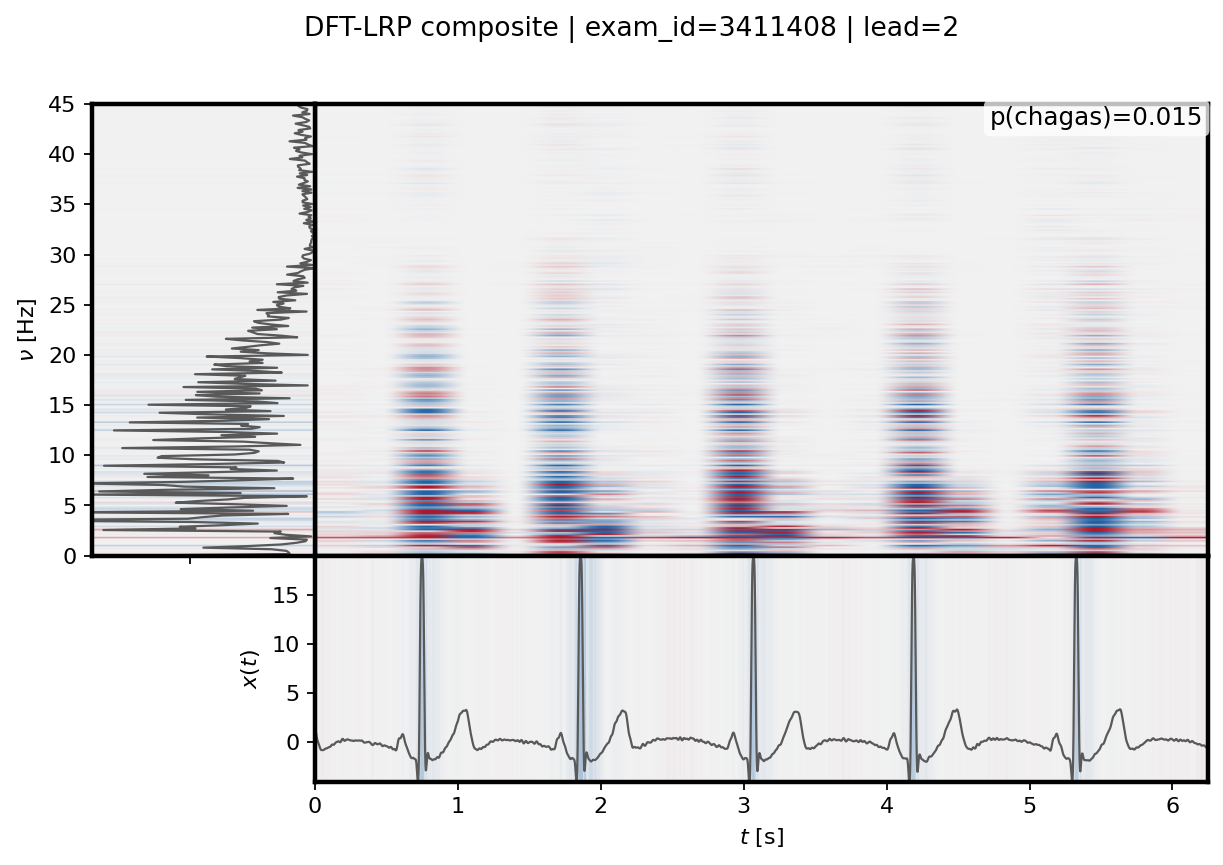

In [6]:
import matplotlib as mpl

# --- knobs ---
CENTER = "signal"  # "signal" (paper-like) or "relevance"
FREQ_MAX_HZ = 45.0     # match the paper look; set to 45.0 for full bandpass
TIME_MAX_S = None      # set e.g. 1.2 to zoom; None uses full window
ALPHA_TIME = 0.35
ALPHA_FREQ = 0.35
EPS = 1e-12
TF_Q = 0.97  # quantile for TF relevance contrast (smaller -> more saturation)
MID_COLOR = "#f2f2f2"  # less harsh than pure white
CMAP_DIV = mpl.colors.LinearSegmentedColormap.from_list("RdBuGrey", ["#2166ac", MID_COLOR, "#b2182b"])

# --- axes in seconds/Hz ---
t = np.arange(T, dtype=np.float32) / FS_HZ
freqs = np.fft.rfftfreq(T, d=1.0 / FS_HZ)
fmask = freqs <= float(FREQ_MAX_HZ)
k_max = int(np.where(fmask)[0][-1]) + 1 if np.any(fmask) else min(200, len(freqs))

# Select the sample/lead we already computed
x_t = signal_time[sample_idx].astype(np.float32)
r_t = relevance_time_1d[sample_idx].astype(np.float32)
a_f = np.abs(signal_freq[0, :k_max]).astype(np.float32)
r_f = np.asarray(relevance_freq[0, :k_max]).astype(np.float32)

# Robust normalization for signed relevance overlays
def _robust_norm_signed(x: np.ndarray, q: float = 0.99) -> np.ndarray:
    s = np.quantile(np.abs(x), q) + EPS
    return np.clip(x / s, -1.0, 1.0)

r_tn = _robust_norm_signed(r_t)
r_fn = _robust_norm_signed(r_f)

# Main TF matrices: upstream STDFT returns [1, n_windows, F]
tf_sig = np.abs(np.asarray(signal_timefreq)[0, :, :k_max]).T.astype(np.float32)
tf_rel = np.asarray(relevance_timefreq)[0, :, :k_max].T.astype(np.float32)

# Optional zoom
t_end = float(t[-1])
if TIME_MAX_S is not None:
    t_end = float(min(t_end, TIME_MAX_S))
    tmask = t <= t_end
    x_t = x_t[tmask]
    r_tn = r_tn[tmask]
    t = t[tmask]

# Map TF x-extent using upstream window stepping
n_windows = tf_sig.shape[1]
window_step = int(WINDOW_WIDTH // max(WINDOW_SHIFT, 1))
tf_t_end = (n_windows * window_step) / FS_HZ
tf_t_end = min(tf_t_end, t_end)

# Robust scaling for the TF relevance colormap
v = np.quantile(np.abs(tf_rel), TF_Q) + EPS

fig = plt.figure(figsize=(9.0, 5.5), dpi=160)
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[1.2, 4.8],
    height_ratios=[3.2, 1.6],
    wspace=0.0, hspace=0.0,
)

ax_tf = fig.add_subplot(gs[0, 1])
ax_spec = fig.add_subplot(gs[0, 0], sharey=ax_tf)
ax_time = fig.add_subplot(gs[1, 1], sharex=ax_tf)

# ---- center: TF ----
if CENTER == "signal":
    # grayscale signal TF with relevance alpha overlay
    ax_tf.imshow(
        tf_sig,
        aspect="auto", origin="lower",
        extent=[0.0, tf_t_end, 0.0, float(freqs[k_max-1])],
        cmap="gray_r",
    )
    ax_tf.imshow(
        tf_rel,
        aspect="auto", origin="lower",
        extent=[0.0, tf_t_end, 0.0, float(freqs[k_max-1])],
        cmap=CMAP_DIV,
        norm=mpl.colors.TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v),
        alpha=0.95,
    )
else:
    ax_tf.imshow(
        tf_rel,
        aspect="auto", origin="lower",
        extent=[0.0, tf_t_end, 0.0, float(freqs[k_max-1])],
        cmap=CMAP_DIV,
        norm=mpl.colors.TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v),
    )

ax_tf.set_xlim(0.0, t_end)
ax_spec.set_ylabel(r"$\nu$ [Hz]")
ax_tf.set_ylim(0.0, float(FREQ_MAX_HZ))
ax_tf.text(
    0.995, 0.995,
    f"p(chagas)={prob_sample:.3f}",
    transform=ax_tf.transAxes,
    ha="right", va="top",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", boxstyle="round,pad=0.25"),
)
ax_tf.set_ylabel(r"$u$ [Hz]")
ax_tf.tick_params(labelbottom=False, labelleft=False, left=False)

# ---- bottom: time signal + signed relevance overlay ----
ymin = float(np.quantile(x_t, 0.01))
ymax = float(np.quantile(x_t, 0.99))
pad = 0.05 * (ymax - ymin + EPS)
ymin -= pad
ymax += pad

time_img = np.tile(r_tn[None, :], (2, 1))
ax_time.imshow(
    time_img,
    aspect="auto", origin="lower",
    extent=[float(t[0]), float(t[-1]), ymin, ymax],
    cmap=CMAP_DIV, vmin=-1.0, vmax=1.0,
    alpha=ALPHA_TIME,
)
ax_time.plot(t, x_t, color="0.35", lw=1.0)
ax_time.set_xlim(0.0, t_end)
ax_time.set_ylim(ymin, ymax)
ax_time.set_xlabel(r"$t$ [s]")
ax_time.set_ylabel(r"$x(t)$")

# ---- left: spectrum + signed relevance overlay (horizontal stripes) ----
f = freqs[:k_max].astype(np.float32)
amp_max = float(np.quantile(a_f, 0.99) + EPS)
spec_img = np.tile(r_fn[:, None], (1, 2))
ax_spec.imshow(
    spec_img,
    aspect="auto", origin="lower",
    extent=[0.0, amp_max, 0.0, float(f[-1])],
    cmap=CMAP_DIV, vmin=-1.0, vmax=1.0,
    alpha=ALPHA_FREQ,
)
ax_spec.plot(a_f, f, color="0.35", lw=1.0)
ax_spec.set_ylim(0.0, float(FREQ_MAX_HZ))
ax_spec.set_xlim(0.0, amp_max)
ax_spec.invert_xaxis()
ax_spec.tick_params(labelbottom=False)

# Aesthetics: slightly gray background for less harsh contrast
for a in (ax_spec, ax_tf, ax_time):
    a.set_facecolor(MID_COLOR)

# Make the axes touch like the paper
for a in (ax_spec, ax_tf, ax_time):
    for spine in a.spines.values():
        spine.set_linewidth(2.0)

title_id = exam_id[sample_idx] if isinstance(exam_id, (list, tuple)) else exam_id
fig.suptitle(f"DFT-LRP composite | exam_id={title_id} | lead={LEAD_INDEX+1}", y=0.98)
plt.show()


## 6) Pixel-flipping sanity check (frequency ablation)

This tests whether the frequency relevance is predictive: remove frequency components and measure the drop in predicted probability.


Original p(chagas)=0.0148 | bandstop[5,15]Hz p=0.0788 | Δ=+0.0640


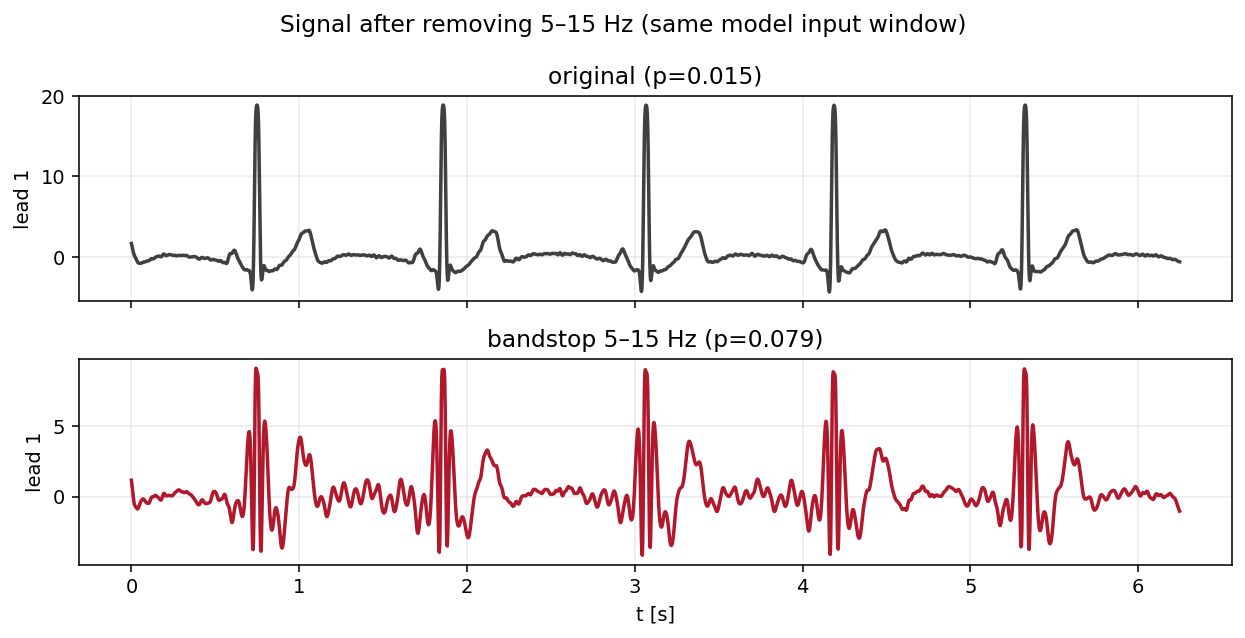

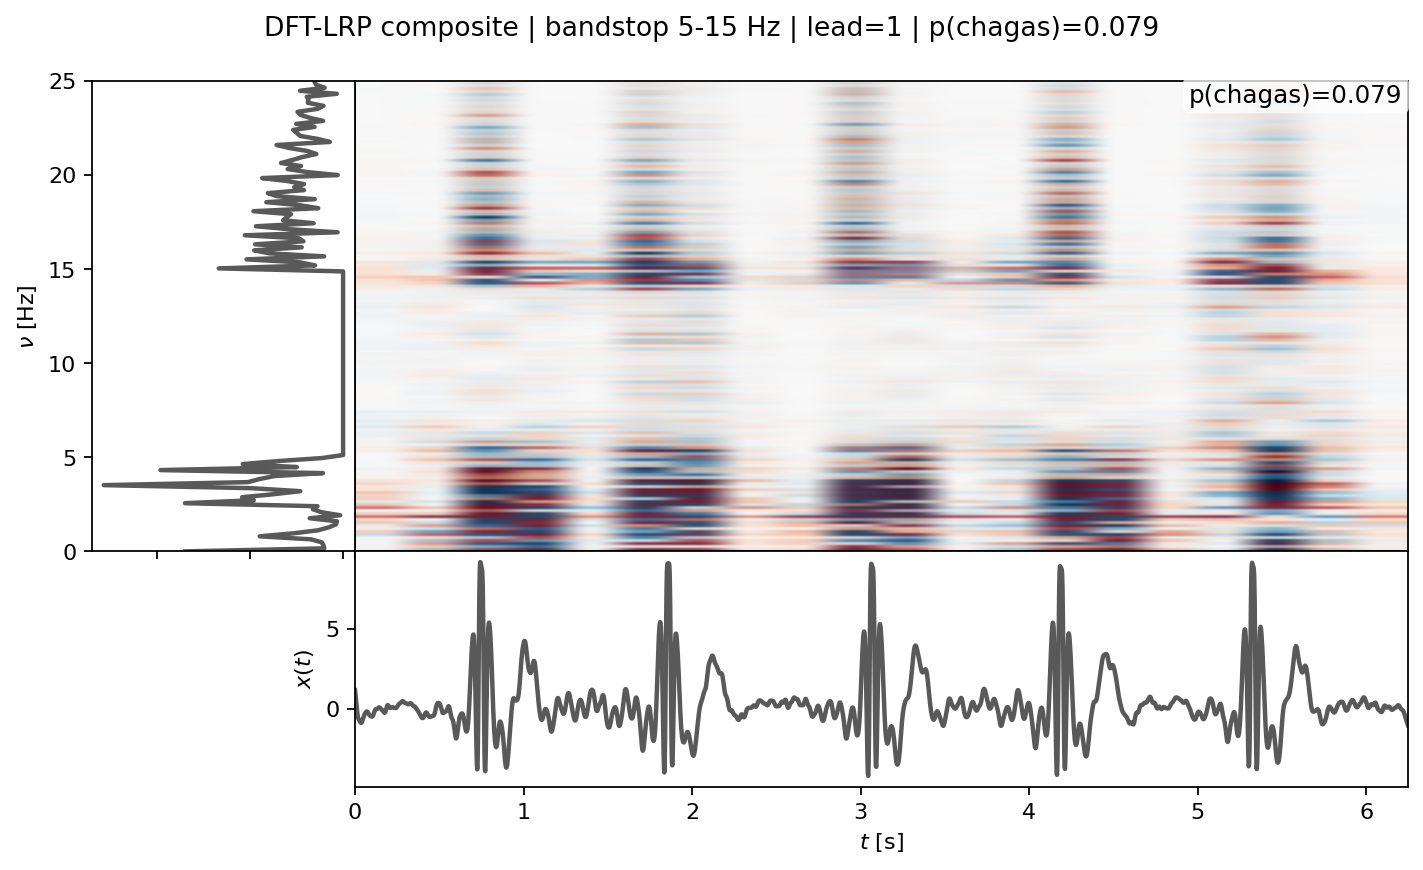

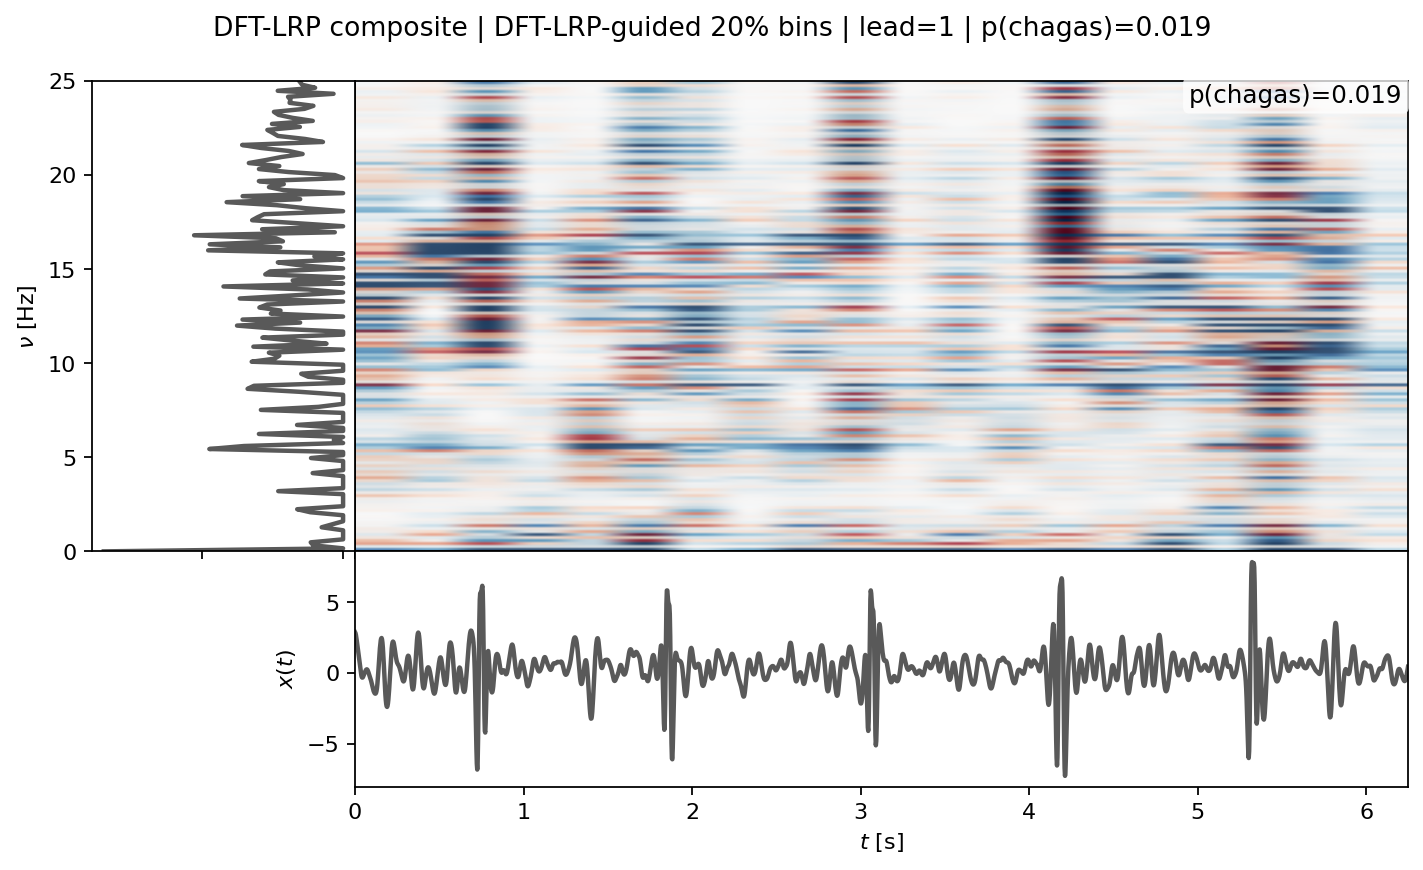

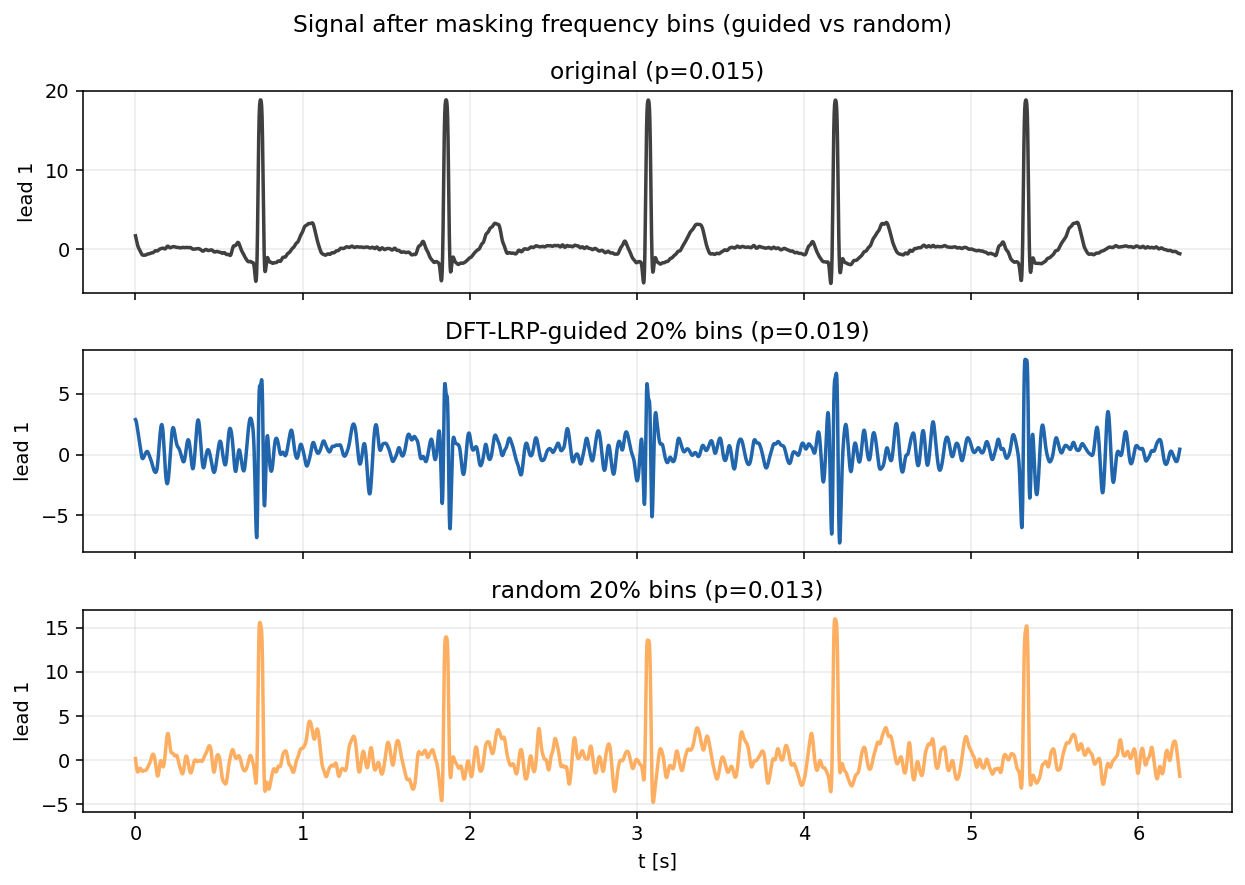

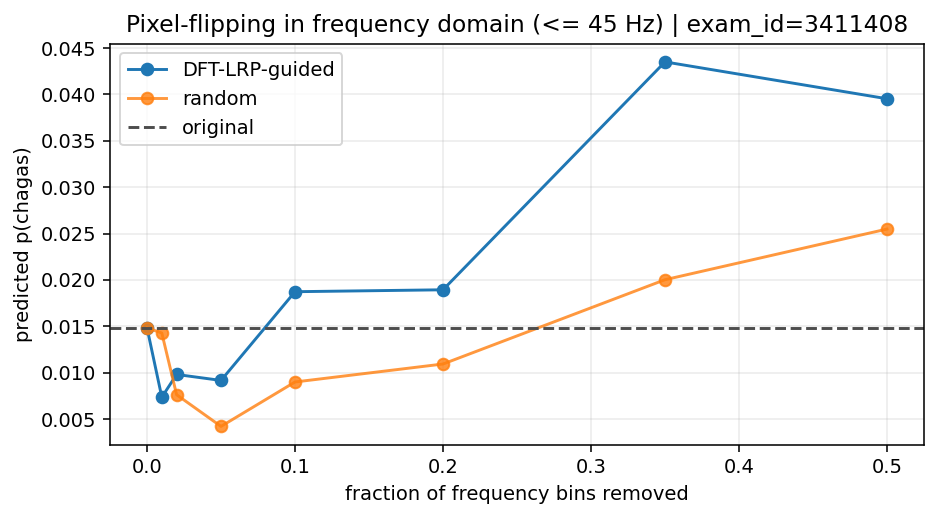

In [7]:
from dataclasses import dataclass

@dataclass
class FlipResult:
    frac_removed: float
    p: float

def _pos_logit(out: torch.Tensor | tuple | list) -> torch.Tensor:
    if isinstance(out, (tuple, list)):
        out = out[-1]
    if out.ndim == 2 and out.shape[1] == 1:
        out = out[:, 0]
    return out

def _predict_prob(x_in: np.ndarray) -> float:
    xt = torch.from_numpy(x_in).to(device=device, dtype=torch.float32)
    with torch.no_grad():
        logit = _pos_logit(model(xt))
        return float(torch.sigmoid(logit)[0].item())

def _bandstop(x_in: np.ndarray, f_lo: float, f_hi: float) -> np.ndarray:
    # x_in: [1,12,T]
    x0 = x_in[0]
    X = np.fft.rfft(x0, axis=-1)
    freqs = np.fft.rfftfreq(x0.shape[-1], d=1.0 / FS_HZ)
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    X[:, mask] = 0
    x_bs = np.fft.irfft(X, n=x0.shape[-1], axis=-1).astype(np.float32)
    return x_bs[None, ...]

# --- single-band ablation (e.g. 5–15 Hz) ---
x_one = x[[sample_idx]].detach().cpu().numpy().astype(np.float32)
T_local = int(x_one.shape[-1])
p_orig = _predict_prob(x_one)
x_bs = _bandstop(x_one, 5.0, 15.0)
p_bs = _predict_prob(x_bs)
print(f"Original p(chagas)={p_orig:.4f} | bandstop[5,15]Hz p={p_bs:.4f} | Δ={p_bs - p_orig:+.4f}")

# Optional: also render the Fig.7-like composite for masked signals
SHOW_MASKED_COMPOSITES = True  # set True to recompute DFT-LRP composite for masked inputs
MASKED_FREQ_MAX_HZ = 25.0

def _choose_window_width(signal_length: int, preferred: int = 128, min_w: int = 32, max_w: int = 512) -> int:
    upper = min(max_w, signal_length)
    candidates = [w for w in range(min_w, upper + 1) if signal_length % w == 0]
    if not candidates:
        return signal_length
    return min(candidates, key=lambda w: abs(w - preferred))

def _plot_composite_for_x(x_np: np.ndarray, title_suffix: str) -> None:
    # x_np: [1,12,T]
    xt = torch.from_numpy(x_np).to(device=device, dtype=torch.float32)
    with torch.no_grad():
        logit = _pos_logit(model(xt))
        p = float(torch.sigmoid(logit)[0].item())
    with torch.inference_mode(False), torch.enable_grad(), torch.autocast(device_type=device.type, enabled=False):
        r_time = compute_lrp_relevance_time(pl_module=model, x=xt)
    Tt = x_np.shape[-1]
    lead = int(LEAD_INDEX)
    sig_t = x_np[0, lead]
    rel_t = r_time.detach().cpu().numpy()[0, lead].astype(np.float32)
    # DFT-LRP freq
    dft_obj = dft_lrp.DFTLRP(Tt, leverage_symmetry=True, precision=32, cuda=False, create_stdft=False, create_inverse=False)
    sig_f, rel_f = dft_obj.dft_lrp(rel_t[None, :], sig_t[None, :], real=False, short_time=False, epsilon=1e-6)
    # STDFT
    ww = _choose_window_width(Tt, preferred=128)
    ws = 1
    tf_obj = dft_lrp.DFTLRP(Tt, leverage_symmetry=True, precision=32, cuda=False, window_shift=ws, window_width=ww, window_shape="rectangle", create_dft=False, create_inverse=False)
    sig_tf, rel_tf = tf_obj.dft_lrp(rel_t[None, :], sig_t[None, :], real=False, short_time=True, epsilon=1e-6)
    sig_tf = np.nan_to_num(sig_tf, nan=0.0, posinf=0.0, neginf=0.0)
    rel_tf = np.nan_to_num(rel_tf, nan=0.0, posinf=0.0, neginf=0.0)
    # Reuse the composite style choices from cell 11 (simple variant)
    t = np.arange(Tt, dtype=np.float32) / FS_HZ
    freqs = np.fft.rfftfreq(Tt, d=1.0 / FS_HZ)
    fmask = freqs <= float(MASKED_FREQ_MAX_HZ)
    k_max = int(np.where(fmask)[0][-1]) + 1 if np.any(fmask) else min(200, len(freqs))
    tf_sig = np.abs(np.asarray(sig_tf)[0, :, :k_max]).T
    tf_rel = np.asarray(rel_tf)[0, :, :k_max].T
    v = np.quantile(np.abs(tf_rel), 0.95) + 1e-12
    fig = plt.figure(figsize=(9.0, 5.5), dpi=160)
    gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 4.8], height_ratios=[3.2, 1.6], wspace=0.0, hspace=0.0)
    ax_tf = fig.add_subplot(gs[0, 1])
    ax_spec = fig.add_subplot(gs[0, 0], sharey=ax_tf)
    ax_time = fig.add_subplot(gs[1, 1], sharex=ax_tf)
    ax_tf.imshow(tf_sig, aspect="auto", origin="lower", extent=[0.0, t[-1], 0.0, float(freqs[k_max-1])], cmap="gray_r")
    ax_tf.imshow(tf_rel, aspect="auto", origin="lower", extent=[0.0, t[-1], 0.0, float(freqs[k_max-1])], cmap="RdBu_r", vmin=-v, vmax=v, alpha=0.7)
    ax_tf.set_xlim(0.0, t[-1])
    ax_tf.set_ylim(0.0, float(MASKED_FREQ_MAX_HZ))
    ax_tf.tick_params(labelbottom=False, labelleft=False, left=False)
    ax_tf.text(0.995, 0.995, f"p(chagas)={p:.3f}", transform=ax_tf.transAxes, ha="right", va="top", fontsize=11, bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", boxstyle="round,pad=0.25"))
    ax_spec.set_ylabel(r"$\nu$ [Hz]")
    a_f = np.abs(np.asarray(sig_f)[0, :k_max])
    ax_spec.plot(a_f, freqs[:k_max], color="0.35", lw=2.0)
    ax_spec.invert_xaxis()
    ax_spec.set_ylim(0.0, float(MASKED_FREQ_MAX_HZ))
    ax_spec.tick_params(labelbottom=False)
    ax_time.plot(t, sig_t, color="0.35", lw=2.0)
    ax_time.set_xlabel(r"$t$ [s]")
    ax_time.set_ylabel(r"$x(t)$")
    fig.suptitle(f"DFT-LRP composite | {title_suffix} | lead={lead} | p(chagas)={p:.3f}", y=0.98)
    fig.tight_layout()
    plt.show()


# Plot original vs bandstop (time domain, one lead)
lead = int(LEAD_INDEX)
t_full = np.arange(T_local, dtype=np.float32) / FS_HZ
x_orig_1d = x_one[0, lead]
x_bs_1d = x_bs[0, lead]

fig, axs = plt.subplots(2, 1, figsize=(9.0, 4.6), dpi=140, sharex=True)
axs[0].plot(t_full, x_orig_1d, color="0.25", lw=1.8)
axs[0].set_title(f"original (p={p_orig:.3f})")
axs[1].plot(t_full, x_bs_1d, color="#b2182b", lw=1.8)
axs[1].set_title(f"bandstop 5–15 Hz (p={p_bs:.3f})")
for ax in axs:
    ax.grid(True, alpha=0.25)
    ax.set_ylabel(f"lead {lead}")
axs[1].set_xlabel("t [s]")
fig.suptitle("Signal after removing 5–15 Hz (same model input window)")
fig.tight_layout()
plt.show()

# --- DFT-LRP-guided pixel-flipping in frequency domain ---
# Compute per-lead frequency relevance for this sample
with torch.inference_mode(False), torch.enable_grad(), torch.autocast(device_type=device.type, enabled=False):
    r_time = compute_lrp_relevance_time(pl_module=model, x=x[[sample_idx]])  # [1,12,T]

freqs = np.fft.rfftfreq(T_local, d=1.0 / FS_HZ)
FREQ_MAX_FLIP = 45.0
allow = (freqs > 0) & (freqs <= FREQ_MAX_FLIP)

# DFT-LRP frequency relevance (vectorized across leads)
x_np = x_one[0]  # [12,T]
r_np = r_time.detach().cpu().numpy()[0].astype(np.float32)  # [12,T]
dftlrp_local = dft_lrp.DFTLRP(T_local, leverage_symmetry=True, precision=32, cuda=False, create_stdft=False, create_inverse=False)
_, rel_f = dftlrp_local.dft_lrp(r_np, x_np, real=False, short_time=False, epsilon=1e-6)
rel_f = np.asarray(rel_f).astype(np.float32)  # [12,F]
score = np.sum(np.abs(rel_f), axis=0)  # [F]
score = np.where(allow, score, -np.inf)
order = np.argsort(-score)
order = order[np.isfinite(score[order])]

def _mask_bins(x_in: np.ndarray, bins: np.ndarray) -> np.ndarray:
    x0 = x_in[0]
    X = np.fft.rfft(x0, axis=-1)
    X[:, bins] = 0
    x_rec = np.fft.irfft(X, n=x0.shape[-1], axis=-1).astype(np.float32)
    return x_rec[None, ...]

fractions = [0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.35, 0.50]
guided: list[FlipResult] = []
random: list[FlipResult] = []
rng = np.random.default_rng(0)
valid_bins = order.copy()

for frac in fractions:
    n = int(round(frac * len(valid_bins)))
    bins_g = valid_bins[:n]
    x_g = _mask_bins(x_one, bins_g)
    guided.append(FlipResult(frac, _predict_prob(x_g)))

    bins_r = rng.choice(valid_bins, size=n, replace=False) if n > 0 else np.array([], dtype=int)
    x_r = _mask_bins(x_one, bins_r)
    random.append(FlipResult(frac, _predict_prob(x_r)))


# Guided vs random example signal at a chosen flip fraction
EXAMPLE_FRAC = 0.20
n_ex = int(round(EXAMPLE_FRAC * len(valid_bins)))
bins_g_ex = valid_bins[:n_ex]
bins_r_ex = rng.choice(valid_bins, size=n_ex, replace=False) if n_ex > 0 else np.array([], dtype=int)
x_g_ex = _mask_bins(x_one, bins_g_ex)
x_r_ex = _mask_bins(x_one, bins_r_ex)
p_g_ex = _predict_prob(x_g_ex)
p_r_ex = _predict_prob(x_r_ex)

if SHOW_MASKED_COMPOSITES:
    _plot_composite_for_x(x_bs, "bandstop 5-15 Hz")
    _plot_composite_for_x(x_g_ex, f"DFT-LRP-guided {EXAMPLE_FRAC:.0%} bins")


fig, axs = plt.subplots(3, 1, figsize=(9.0, 6.4), dpi=140, sharex=True)
axs[0].plot(t_full, x_orig_1d, color="0.25", lw=1.8)
axs[0].set_title(f"original (p={p_orig:.3f})")
axs[1].plot(t_full, x_g_ex[0, lead], color="#2166ac", lw=1.8)
axs[1].set_title(f"DFT-LRP-guided {EXAMPLE_FRAC:.0%} bins (p={p_g_ex:.3f})")
axs[2].plot(t_full, x_r_ex[0, lead], color="#fdae61", lw=1.8)
axs[2].set_title(f"random {EXAMPLE_FRAC:.0%} bins (p={p_r_ex:.3f})")
for ax in axs:
    ax.grid(True, alpha=0.25)
    ax.set_ylabel(f"lead {lead}")
axs[2].set_xlabel("t [s]")
fig.suptitle("Signal after masking frequency bins (guided vs random)")
fig.tight_layout()
plt.show()

plt.figure(figsize=(6.8, 3.8), dpi=140)
plt.plot([r.frac_removed for r in guided], [r.p for r in guided], marker="o", label="DFT-LRP-guided")
plt.plot([r.frac_removed for r in random], [r.p for r in random], marker="o", label="random", alpha=0.8)
plt.axhline(p_orig, color="0.3", lw=1.5, ls="--", label="original")
plt.xlabel("fraction of frequency bins removed")
plt.ylabel("predicted p(chagas)")
plt.title(f"Pixel-flipping in frequency domain (<= {FREQ_MAX_FLIP:g} Hz) | exam_id={exam_id[sample_idx] if isinstance(exam_id, (list, tuple)) else exam_id}")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
